In [29]:
# Part 1
@show W = [randn(16, 2), randn(16, 16), randn(1, 16)]
@show b = [zeros(16), zeros(16), zeros(1)]
NN(x, y) = W[3]*tanh.(W[2]*tanh.(W[1]*[x, y]+b[1])+b[2])+b[3]

W = [randn(16, 2), randn(16, 16), randn(1, 16)] = [[1.072463523471029 -1.93337643029648; 0.523231782287188 -0.5687099130889836; 0.8723099464588924 0.5440887971958834; -1.5788174180435557 1.0358593756981898; 1.0745309031591428 2.716474710593413; -0.11173506067553898 3.157960470204406; -0.6223919722963 -0.035788576223018106; 1.2786632389466093 -0.18007082850761055; 0.8643627187362519 0.584608102371713; 2.1343279273399984 0.35645715065885464; 0.18195731955191585 0.28663771713927333; 2.8956329115159614 -0.7233832211444994; -0.3935329003666162 0.5130959866884243; -0.39425371059114805 -0.5897495157136425; -0.4359592274648933 -1.4773945423377242; -1.1787290836494697 0.3639838286322558], [0.22857304263430372 -1.3639802457748034 0.4188815235255033 -1.7352807567270456 -0.7502394213822454 -1.5705313716723939 0.06258067244707509 0.3033975438601528 1.868815337363025 -0.9225377963124134 0.10651544574094976 0.8465173680631074 -2.083654449077786 -1.4210552333134128 1.1974680166857306 -0.77409184122965

NN (generic function with 1 method)

In [30]:
# Part 2
function NN_derivative(x, y, dx, dy)
    z1 = W[1] * [x, y] + b[1]
    z2 = W[2] * tanh.(z1) + b[2]
    W[3] * (sech.(z2) .^ 2 .* (W[2] * (sech.(z1) .^ 2 .* (W[1] * [dx, dy]))))
end


NN_derivative (generic function with 1 method)

In [31]:
# Part 3
function gradient_descent(f, df, u0, alpha; tol = 1e-10, maxiters = 1000, verbose = false)
    un = u0
    step = df(un) * alpha
    epoch = 0
    while sqrt(sum(abs2, step)) >= tol && epoch < maxiters
        epoch += 1
        if verbose
            println("Epoch: ", epoch, " Loss: ", f(un), " Step size: ", sqrt(sum(abs2, step)))
        end
        un = un - step
        step = df(un) * alpha
    end
    [un, f(un)]
end

f(x) = sum(abs2, x)
df(x) = 2 .* x

gradient_descent(f, df, [1.0, 1.0], 0.01)


2-element Vector{Any}:
  [3.482867618819059e-9, 3.482867618819059e-9]
 2.4260733700436688e-17

In [32]:
# Part 4: function definitions
using LinearAlgebra

nn_val(x, y) = first(NN(x, y))
nn_deriv_val(x, y, dx, dy) = first(NN_derivative(x, y, dx, dy))

const _h = 1e-6
nn_x(x, y) = nn_deriv_val(x, y, 1.0, 0.0)
nn_y(x, y) = nn_deriv_val(x, y, 0.0, 1.0)
nn_xx(x, y) = (nn_x(x + _h, y) - nn_x(x - _h, y)) / (2 * _h)
nn_yy(x, y) = (nn_y(x, y + _h) - nn_y(x, y - _h)) / (2 * _h)

g(x, y) = x * (1 - x) * y * (1 - y)
g_x(x, y) = y * (1 - y) * (1 - 2x)
g_xx(x, y) = -2 * y * (1 - y)
g_y(x, y) = x * (1 - x) * (1 - 2y)
g_yy(x, y) = -2 * x * (1 - x)

function u_pred(x, y)
    n = nn_val(x, y)
    n_x = nn_x(x, y)
    n_y = nn_y(x, y)
    n_xx = nn_xx(x, y)
    n_yy = nn_yy(x, y)
    g_ = g(x, y)
    gx_ = g_x(x, y)
    gy_ = g_y(x, y)
    gxx_ = g_xx(x, y)
    gyy_ = g_yy(x, y)
    u_xx = gxx_ * n + 2 * gx_ * n_x + g_ * n_xx
    u_yy = gyy_ * n + 2 * gy_ * n_y + g_ * n_yy
    (; u_xx, u_yy)
end

const n_colloc = 15
const _xs = [(i / (n_colloc + 1)) for i = 1:n_colloc]
const _ys = [(j / (n_colloc + 1)) for j = 1:n_colloc]

function poisson_loss_at(u_params)
    unpack!(u_params)
    residual_sq = 0.0
    for x in _xs
        for y in _ys
            (; u_xx, u_yy) = u_pred(x, y)
            rhs = sin(pi * x) * sin(pi * y)
            residual = u_xx + u_yy + rhs
            residual_sq += residual^2
        end
    end
    residual_sq / (n_colloc * n_colloc)
end

function pack!(W, b)
    vcat(vec(W[1]), vec(W[2]), vec(W[3]), vec(b[1]), vec(b[2]), vec(b[3]))
end
function unpack!(v)
    i = 0
    W[1][:] = v[(i+1):(i+32)];
    i += 32
    W[2][:] = v[(i+1):(i+256)];
    i += 256
    W[3][:] = v[(i+1):(i+16)];
    i += 16
    b[1][:] = v[(i+1):(i+16)];
    i += 16
    b[2][:] = v[(i+1):(i+16)];
    i += 16
    b[3][:] = v[(i+1):(i+1)];
    i += 1
    nothing
end

const _eps = 1e-7
function poisson_loss_grad(u_params)
    grad = similar(u_params)
    f0 = poisson_loss_at(u_params)
    for i in eachindex(u_params)
        u_plus = copy(u_params);
        u_plus[i] += _eps
        u_minus = copy(u_params);
        u_minus[i] -= _eps
        grad[i] = (poisson_loss_at(u_plus) - poisson_loss_at(u_minus)) / (2 * _eps)
    end
    grad
end

poisson_loss_grad (generic function with 1 method)

In [ ]:
# Part 4: training
u0 = pack!(W, b)

alpha = 1e-2
result = gradient_descent(poisson_loss_at, poisson_loss_grad, u0, alpha; tol = 1e-4, maxiters = 500, verbose = true)
u_opt, loss_opt = result
unpack!(u_opt)

using Serialization

@show my_data = Dict(:W => W, :b => b)
serialize("hw1.jls", my_data)
my_data_from_serialized = deserialize("hw1.jls")
@assert my_data == my_data_from_serialized

In [33]:
# Part 4: loading parameters
using Serialization

my_data_from_serialized = deserialize("hw1.jls")
W = my_data_from_serialized[:W]
b = my_data_from_serialized[:b]
u_opt = pack!(W, b)

loss_opt = poisson_loss_at(u_opt)
println("Final loss: ", loss_opt)

Final loss: 0.007574933663770549


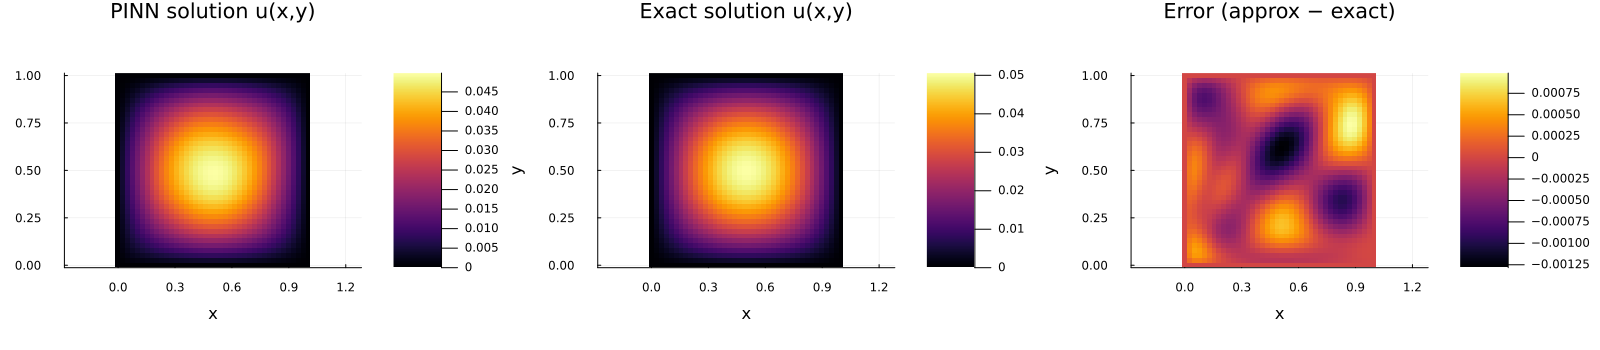

In [34]:
# Visualization
u_exact(x, y) = sin(pi * x) * sin(pi * y) / (pi^2) / 2

using Plots

n_plot = 40
x_plot = range(0, 1; length = n_plot)
y_plot = range(0, 1; length = n_plot)
Z_approx = [u_approx(x, y) for x in x_plot, y in y_plot]
Z_exact = [u_exact(x, y) for x in x_plot, y in y_plot]

p1 = heatmap(
    x_plot,
    y_plot,
    Z_approx';
    xlabel = "x",
    ylabel = "y",
    title = "PINN solution u(x,y)",
    aspect_ratio = 1,
)
p2 = heatmap(
    x_plot,
    y_plot,
    Z_exact';
    xlabel = "x",
    ylabel = "y",
    title = "Exact solution u(x,y)",
    aspect_ratio = 1,
)
p3 = heatmap(
    x_plot,
    y_plot,
    (Z_approx .- Z_exact)';
    xlabel = "x",
    ylabel = "y",
    title = "Error (approx − exact)",
    aspect_ratio = 1,
)

plot(p1, p2, p3; layout = (1, 3), size = (1600, 350))
